In [44]:
from ema_workbench import (
    Model, Policy, ema_logging,
    MultiprocessingEvaluator, save_results, load_results, Scenario
)
from ema_workbench.analysis import prim, cart, parcoords
from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from concurrent.futures import ProcessPoolExecutor
import os
import itertools
import functools
import random
from assignment_10_scenario_selection import find_maxdiverse_scenarios
from ema_workbench.analysis import dimensional_stacking

In [46]:
dike_model, planning_steps = get_model_for_problem_formulation(3)

In [ ]:
# Enable logging
ema_logging.log_to_stderr(ema_logging.INFO)

# Load model formulation
dike_model, planning_steps = get_model_for_problem_formulation(3)

# Create a "do nothing" policy (no investment in any lever)
do_nothing = Policy("do nothing", **{lev.name: 0 for lev in dike_model.levers})

# Choose number of scenarios
n_scenarios = 10000  # Literature suggests 1000–10,000, this is a balanced choice

# Run model for scenarios with 1 policy
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=n_scenarios, policies=[do_nothing])
    save_results(results, "scenario_selection.tar.gz")

In [45]:
# Load experiments and outcomes from saved file
experiments, outcomes = load_results('scenario_selection.tar.gz')

[MainProcess/INFO] results loaded successfully from /Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/final assignment/scenario_selection.tar.gz


In [47]:
# 1 = median filter, 2 = percentile filter, 3 = diversity-based selection
SELECTION_METHOD = 2  # Change this to 1, 2, or 3

# Define outcomes and preferences
outcome_names = [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
]
preferences = {name: +1 for name in outcome_names}  # All to be minimized

# --- SCENARIO FILTERING ---
if SELECTION_METHOD == 1:
    # Median-based filtering
    thresholds = {o: np.median(outcomes[o]) for o in outcome_names}
    y = np.ones(len(experiments), dtype=bool)
    for o in outcome_names:
        if preferences[o] == +1:
            y &= outcomes[o] >= thresholds[o]
        else:
            y &= outcomes[o] <= thresholds[o]

elif SELECTION_METHOD == 2:
    # Percentile-based filtering
    percentile_threshold = 90  # Choose percentile for "worse" scenarios
    thresholds = {
        o: np.percentile(outcomes[o], percentile_threshold if preferences[o] == +1 else (100 - percentile_threshold))
        for o in outcome_names
    }
    y = np.ones(len(experiments), dtype=bool)
    for o in outcome_names:
        if preferences[o] == +1:
            y &= outcomes[o] >= thresholds[o]
        else:
            y &= outcomes[o] <= thresholds[o]

elif SELECTION_METHOD == 3:
    # No initial filtering for diversity; use all experiments
    y = np.ones(len(experiments), dtype=bool)

else:
    raise ValueError("Invalid SELECTION_METHOD. Choose 1 (median), 2 (percentile), or 3 (diversity)")

# Subset experiments and outcomes
experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items() if k in outcome_names})

# --- SCENARIO SELECTION ---
if SELECTION_METHOD == 3:
    # --- DIVERSITY-BASED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    distances = squareform(pdist(normalized_outcomes.values))
    sampled_combinations = [random.sample(range(len(normalized_outcomes)), 2) for _ in range(100000)]

    partial_function = functools.partial(find_maxdiverse_scenarios, distances)
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        worker_data = np.array_split(sampled_combinations, os.cpu_count())
        results = list(itertools.chain.from_iterable(executor.map(partial_function, worker_data)))

    results.sort(key=lambda entry: entry[0], reverse=True)
    diversity_score, best_indices = results[0]

    print(f"\nMost diverse scenario indices: {best_indices}")

else:
    # --- BEST/WORST-CASE AGGREGATED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    best_index = normalized_outcomes.sum(axis=1).idxmin()
    worst_index = normalized_outcomes.sum(axis=1).idxmax()
    best_indices = [
        normalized_outcomes.index.get_loc(best_index),
        normalized_outcomes.index.get_loc(worst_index)
    ]

    print(f"\nBest/Worst scenario indices: {[best_index, worst_index]}")

# --- Common output ---
true_indices = outcomes_df.iloc[list(best_indices)].index
selected_experiments = experiments.loc[true_indices]
selected_outcomes = pd.DataFrame({k: outcomes[k][true_indices] for k in outcome_names})


Best/Worst scenario indices: [608, 654]


In [48]:
selected_outcomes

,RfR Total Costs,Expected Evacuation Costs,A.5 Total Costs,A.5_Expected Number of Deaths
0,0.0,0.0,0.000000e+00,0.000000
1,0.0,0.0,2.293078e+08,0.213336


In [49]:
selected_experiments

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
608,17,318.159840,1.5,0.114236,348.733554,10.0,0.295943,137.593877,1.0,0.421135,...,0,0,0,0,0,0,0,608,do nothing,dikesnet
654,66,325.909809,1.5,0.544821,247.261599,1.0,0.962876,100.860332,1.5,0.744246,...,0,0,0,0,0,0,0,654,do nothing,dikesnet


  0%|                                                  | 0/100 [26:16<?, ?it/s]


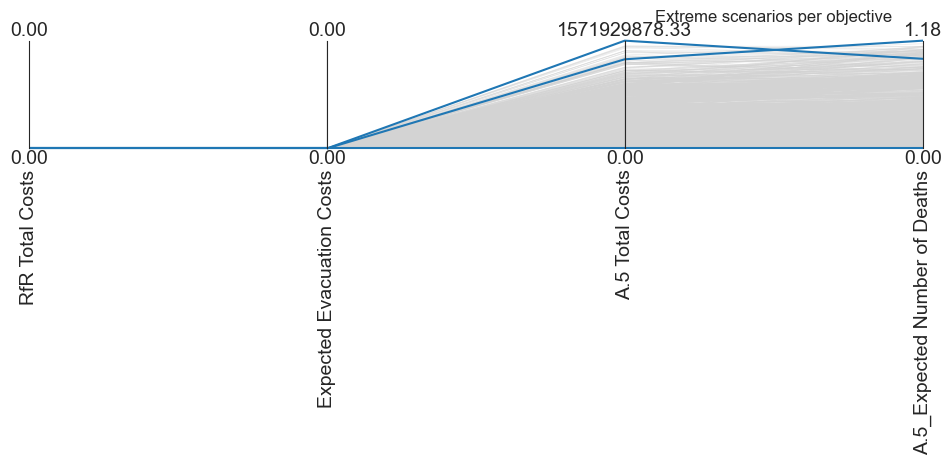

In [50]:
# STEP 4: Parallel coordinates plot with extremes
all_data = pd.DataFrame({k: outcomes[k] for k in outcome_names})
extreme_indices = pd.concat([all_data.idxmin(), all_data.idxmax()]).unique()
limits = parcoords.get_limits(all_data)
axes = parcoords.ParallelAxes(limits)
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)
axes.plot(all_data.loc[extreme_indices], color=sns.color_palette()[0], lw=1.5)
fig = plt.gcf()
fig.set_size_inches((10, 4))
plt.title("Extreme scenarios per objective")
plt.show()


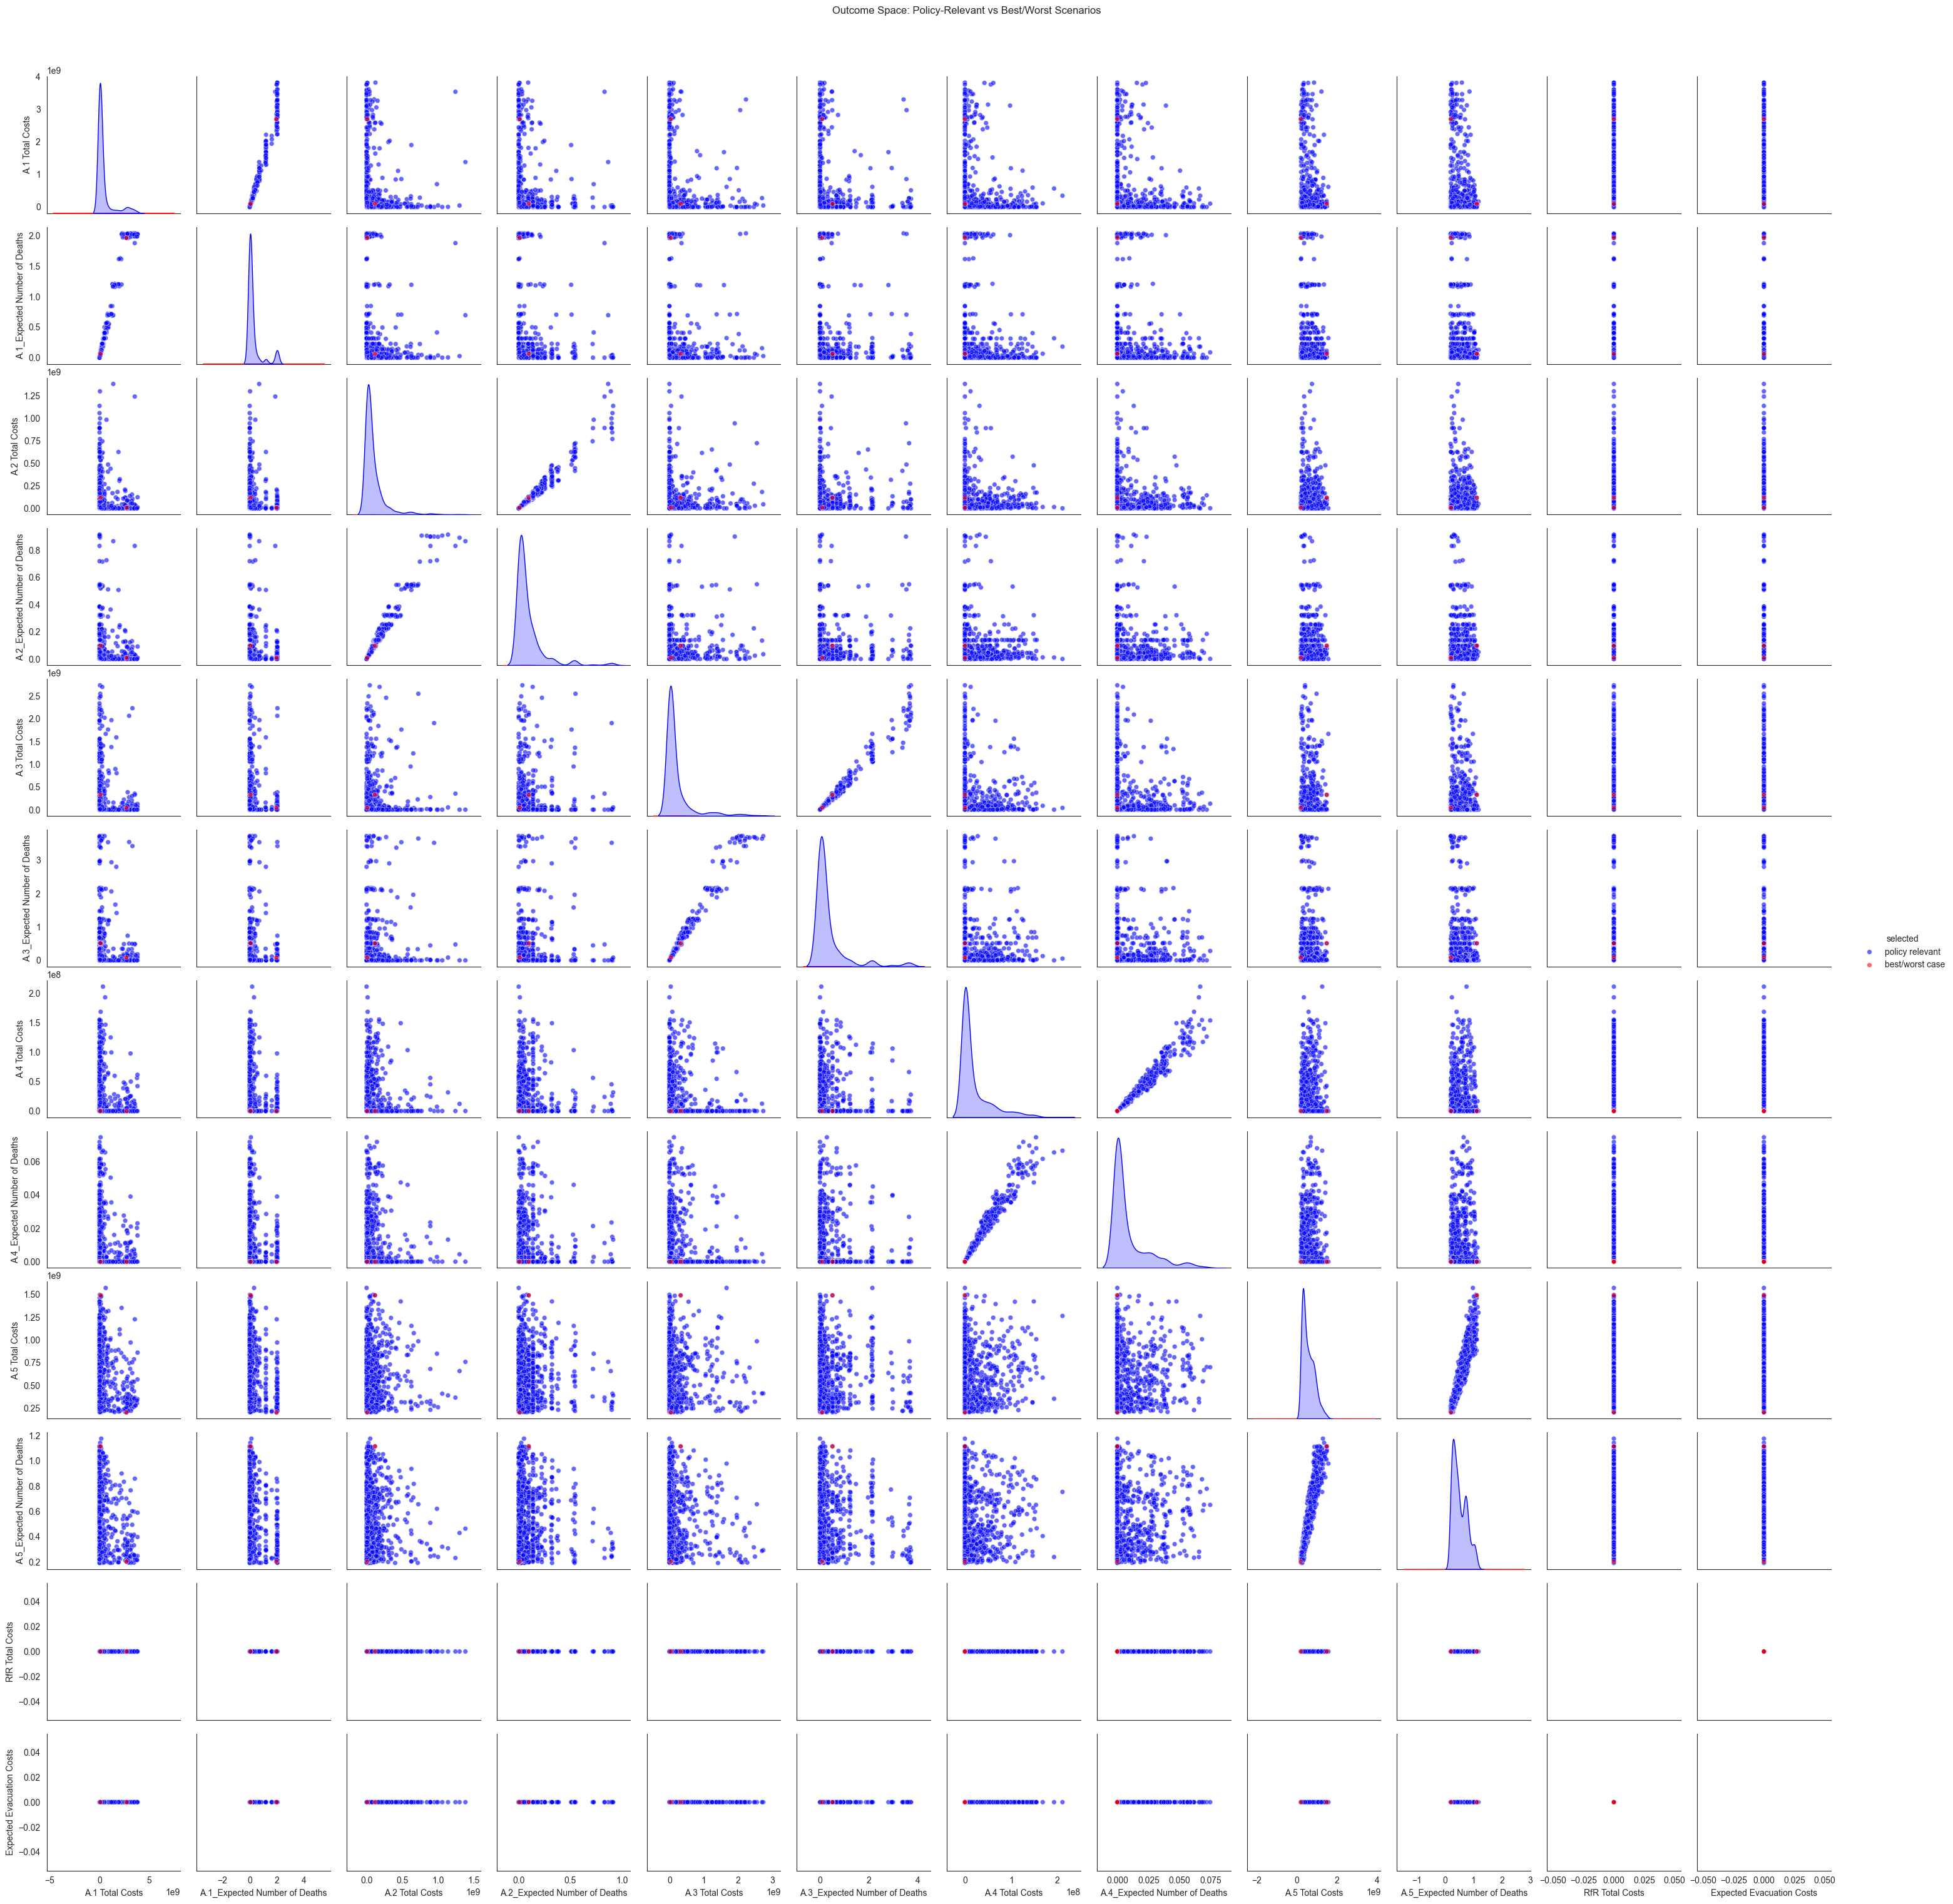

In [51]:
# STEP 5: Full outcome space pairplot (all outcomes)
full_outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items()})
full_outcomes_df = full_outcomes_df.copy()
full_outcomes_df['selected'] = 'policy relevant'
selected_labeled = full_outcomes_df.loc[true_indices].copy()
selected_labeled['selected'] = 'best/worst case'
combined_outcomes = pd.concat([full_outcomes_df, selected_labeled])

sns.pairplot(
    combined_outcomes,
    vars=full_outcomes_df.columns.drop('selected'),
    hue='selected',
    palette={'policy relevant': 'blue', 'best/worst case': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Best/Worst Scenarios', y=1.02)
plt.show()


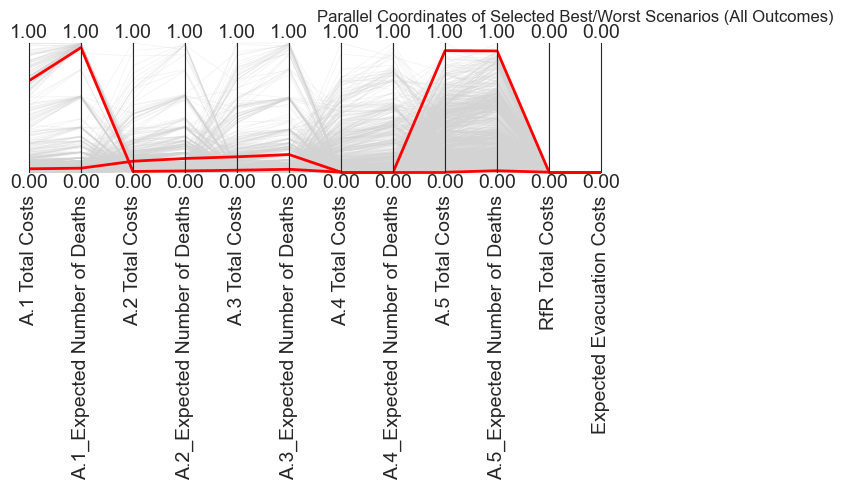

In [52]:
from sklearn.preprocessing import minmax_scale
from ema_workbench.analysis import parcoords

# Use all outcomes (not just selected ones)
full_combined_data = pd.DataFrame({k: v[y] for k, v in outcomes.items()})  # only policy-relevant
normalized_all = full_combined_data.copy()
normalized_all[full_combined_data.columns] = minmax_scale(full_combined_data)

# Selected 2 (best and worst case) from earlier
selected_out = normalized_all.loc[true_indices]

# Plot full space and highlight best/worst
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)
ax.plot(normalized_all, color='lightgrey', lw=0.5, alpha=0.3)
ax.plot(selected_out, color='red', lw=2)
plt.title('Parallel Coordinates of Selected Best/Worst Scenarios (All Outcomes)')
plt.show()

In [53]:
print("x shape:", experiments_of_interest.shape)
print("y shape:", y_prim.shape)
print("y dtype:", y_prim.dtype)
print("unieke waarden in y:", y_prim.unique())

x shape: (974, 53)
y shape: (974,)
y dtype: bool
unieke waarden in y: [ True]


In [54]:
outcomes_df['A.5_Expected Number of Deaths'].describe()

count    974.000000
mean       0.508509
std        0.246479
min        0.190762
25%        0.300504
50%        0.449452
75%        0.704794
max        1.176619
Name: A.5_Expected Number of Deaths, dtype: float64

[MainProcess/INFO] column policy dropped from analysis because it has only one category
[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 974 points remaining, containing 253 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.07700205338809035, coverage: 0.2964426877470356, density: 1.0 restricted_dimensions: 9


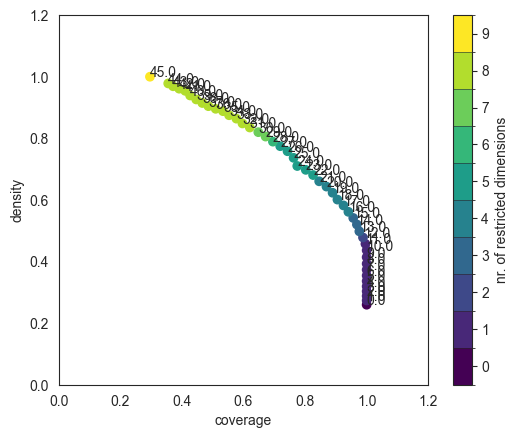

In [65]:
import numpy as np

# Fix voor compatibiliteit met ema_workbench + nieuwe NumPy
if not hasattr(np, 'int'):
    np.int = int
from ema_workbench.analysis import prim

# Binary classification mask for PRIM
# Top 25% van scenario's met hoogste sterfte
threshold = 0.70
y_prim = outcomes_df['A.5_Expected Number of Deaths'] > threshold

# Use experiments_of_interest (same length as y_prim)

prim_alg = prim.Prim(experiments_of_interest, y_prim, threshold=0.8)
box = prim_alg.find_box()
box.show_tradeoff(annotated=True)
plt.show()

In [ ]:
#Hier evt nog wat toevoegen om een aparte box te inspecteren

In [66]:
point = 27
box.inspect(point)

coverage      0.719368
density       0.774468
id           27.000000
k           182.000000
mass          0.241273
mean          0.774468
n           235.000000
res_dim       5.000000
Name: 27, dtype: float64

             box 27                                  
                min       max  qp value      qp value
A.5_pfail  0.000021  0.084736       NaN  3.515239e-51
A.4_pfail  0.290591  0.999076  0.000093           NaN
A.1_pfail  0.373011  0.999615  0.000199           NaN
A.2_pfail  0.191166  0.997765  0.030366           NaN
A.3_pfail  0.182458  0.999415  0.167791           NaN



[None]

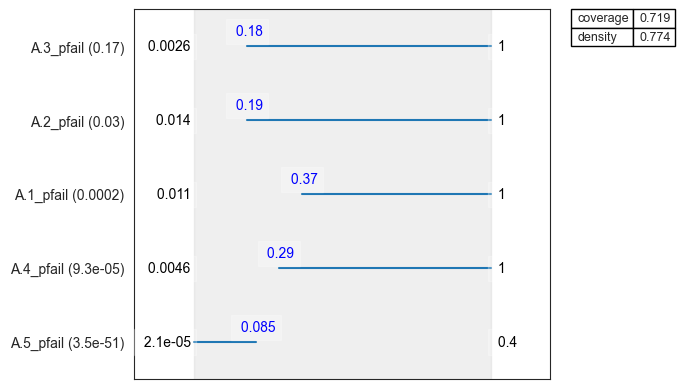

In [67]:
box.inspect(point, style='graph')
plt.show()

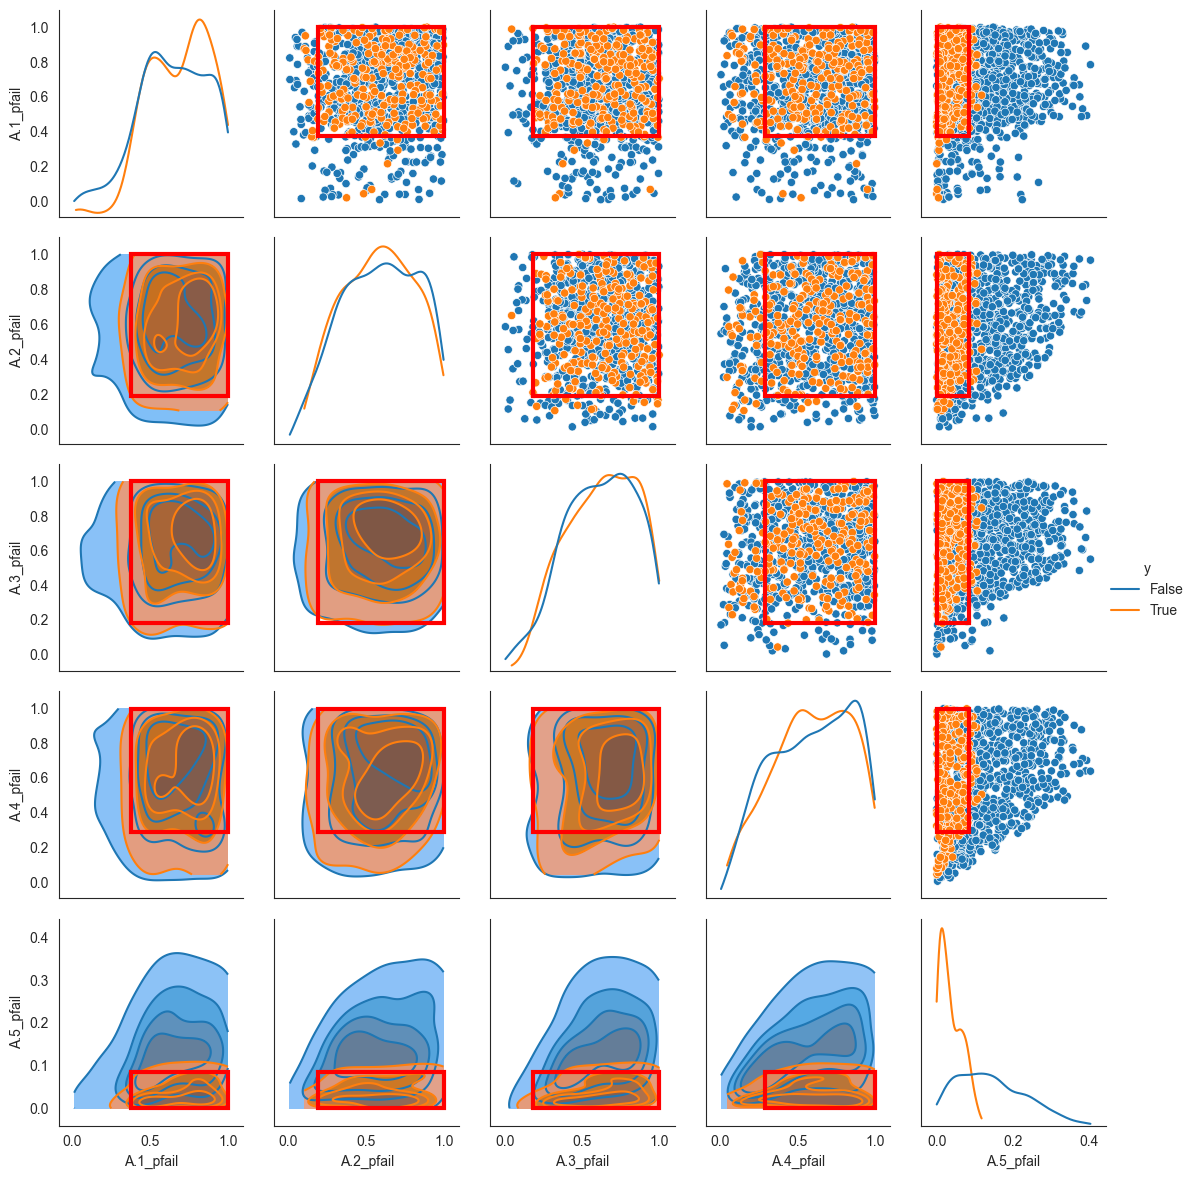

In [68]:
box.select(point)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12,12)
plt.show()

In [69]:
y_array = y_prim.values

[MainProcess/INFO] policy dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category


TypeError: Image data of dtype object cannot be converted to float

<Figure size 800x600 with 0 Axes>

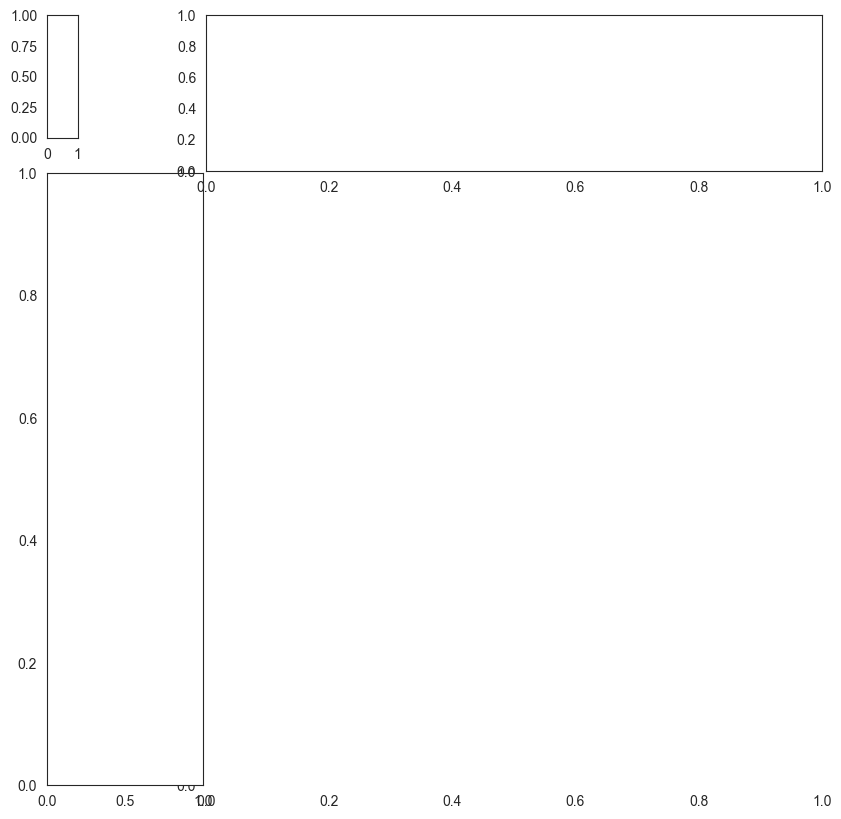

In [71]:
#Hier kan Dimensional Stacking
plt.figure(figsize=(8, 6))
dimensional_stacking.create_pivot_plot(experiments_of_interest, y_array)
plt.tight_layout()
plt.show()

In [56]:
from ema_workbench import Scenario

scenarios = [
    Scenario(f"Scenario {i}", **row.to_dict())
    for i, row in selected_experiments.iterrows()
]

In [57]:
import multiprocessing
print("Number of CPU cores:", multiprocessing.cpu_count())

Number of CPU cores: 8


In [59]:
#Maar 4 objectives of interest
from ema_workbench import ema_logging, Scenario
from ema_workbench.em_framework.optimization import (
    ArchiveLogger, EpsilonProgress, to_problem,
    epsilon_nondominated, HypervolumeMetric, RobustProblem, Problem
)
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import numpy as np
import os

def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

def safe_epsilon_nondominated(df, epsilons, problem):
    eps = []
    for col, eps_val in zip(df.columns, epsilons):
        if df[col].nunique() <= 1:
            eps.append(np.inf)
        else:
            eps.append(eps_val)

    nd_array = epsilon_nondominated([df], eps, problem)
    nd_df = pd.DataFrame(nd_array, columns=df.columns)
    return nd_df

objectives_of_interest = [
    "RfR Total Costs",
    "Expected Evacuation Costs",
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

In [60]:
def run_optimization_for_scenario(scenario, model, objectives_of_interest, epsilons):
    from ema_workbench import Scenario
    from ema_workbench.em_framework.optimization import to_problem, ArchiveLogger, EpsilonProgress, epsilon_nondominated
    from ema_workbench import MultiprocessingEvaluator

    results = []
    convergences = []
    archive_paths = []

    for run_id in range(5):
        print(f"\n🔁 Running optimization for scenario: {scenario.name}, run: {run_id}")

        # Setup model again per run (resetting outcomes)
        model, _ = get_model_for_problem_formulation(3)

        # Filter outcomes
        names_to_keep = []
        for o in model.outcomes:
            if o.name in objectives_of_interest:
                names_to_keep.append(o.name)

        for name in list(model.outcomes.keys()):
            if name not in names_to_keep:
                del model.outcomes[name]

        print(f"✅ Filtered outcomes for scenario {scenario.name} (run {run_id}):")
        for o in model.outcomes:
            print(o.name)

        # Reference scenario
        reference_values = {
                "Bmax": 175, "Brate": 1.5, "pfail": 0.5,
                "discount rate 0": 3.5, "discount rate 1": 3.5,
                "discount rate 2": 3.5, "ID flood wave shape": 4
            }

        scen1 = {}
        for key in model.uncertainties:
            name_split = key.name.split("_")
            key_id = name_split[1] if len(name_split) > 1 else key.name
            scen1[key.name] = reference_values[key_id]

        reference_scenario = Scenario("reference", **scen1)

        # Clean names after optimization
        lever_names = [clean_name(l.name, "L_") for l in model.levers]
        outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

        archive_filename = f"optimization_{scenario.name}_run{run_id}.tar.gz"
        archive_path = f"./archives/{archive_filename}"
        archive_paths.append(archive_path)

        convergence_metrics = [
            ArchiveLogger("./archives", lever_names, outcome_names, base_filename=archive_filename),
            EpsilonProgress()
        ]

        if os.path.exists(archive_path):
            os.remove(archive_path)

        with MultiprocessingEvaluator(model) as evaluator:
            result, convergence = evaluator.optimize(
                nfe=100,
                searchover='levers',
                convergence=convergence_metrics,
                epsilons=epsilons,
                reference=reference_scenario
            )
            results.append(result)
            convergences.append(convergence)

    # Clean names after optimization
    for lever in model.levers:
        lever.name = clean_name(lever.name, "L_")
    for o in model.outcomes:
        o.name = clean_name(o.name, prefix="O_")

    problem = to_problem(model, searchover="levers")

    # Combine all results and apply epsilon_nondominated
    from ema_workbench.em_framework.optimization import epsilon_nondominated
    all_results_df = pd.concat(results, ignore_index=True)
    all_results_df = clean_column_names(all_results_df)
    reference_set = safe_epsilon_nondominated(all_results_df, epsilons, problem)

    return reference_set, results, convergences, archive_paths, problem

In [61]:
def compute_convergence_metrics(scenario_name, reference_set, convergences, archive_paths, problem):
    from ema_workbench.em_framework.optimization import ArchiveLogger, HypervolumeMetric
    metrics = []

    for run_id, (archive_path, convergence) in enumerate(zip(archive_paths, convergences)):
        archives = ArchiveLogger.load_archives(archive_path)
        archives_clean = {k: clean_column_names(v) for k, v in archives.items()}

        # Check constant objectives
        outcome_nunique = reference_set[problem.outcome_names].nunique()
        constant_objectives = outcome_nunique[outcome_nunique <= 1].index.tolist()

        if constant_objectives:
            print(f"⚠️ Constant objectives verwijderd: {constant_objectives}")
            filtered_outcomes = [name for name in problem.outcome_names if name not in constant_objectives]
            if not filtered_outcomes:
                print("❌ Geen bruikbare objectives over. Sla HV over.")
                continue
            proxy_problem = Problem("levers", parameters=problem.parameters,
                                    outcome_names=filtered_outcomes, constraints=[])
            proxy_problem.types = problem.types
            relevant_columns = proxy_problem.parameter_names + proxy_problem.outcome_names
        else:
            proxy_problem = problem
            relevant_columns = problem.parameter_names + problem.outcome_names

        hv = HypervolumeMetric(reference_set[relevant_columns], proxy_problem)

        # ✨ Epsilon progress uitsplitsen per generatie
        epsilons = convergence["epsilon_progress"]

        for (nfe, generation), epsilon in zip(archives_clean.items(), epsilons):
            generation = generation[relevant_columns]
            score = {
                "nfe": nfe,
                "hypervolume": hv.calculate(generation),
                "epsilon_progress": epsilon,
                "seed": run_id,
                "scenario": scenario_name
            }
            metrics.append(score)

    df = pd.DataFrame(metrics).sort_values("nfe").reset_index(drop=True)
    return df


In [62]:
ema_logging.log_to_stderr(ema_logging.INFO)
os.makedirs("./convergence_metrics", exist_ok=True)
os.makedirs("./archives", exist_ok=True)

all_results = []
for scenario in scenarios:
    epsilons = [0.05] * len(objectives_of_interest)

    reference_set, scenario_results, convergences, archive_paths, problem = run_optimization_for_scenario(
        scenario, dike_model, objectives_of_interest, epsilons
    )

    all_results.extend(scenario_results)

    df_metrics = compute_convergence_metrics(
        scenario.name, reference_set, convergences, archive_paths, problem
    )

    df_metrics.to_csv(f"./convergence_metrics/metrics_{scenario.name}.csv", index=False)
    print(f"💾 Saved convergence metrics for scenario {scenario.name}")


🔁 Running optimization for scenario: Scenario 608, run: 0
✅ Filtered outcomes for scenario Scenario 608 (run 0):
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 100/100 [00:06<00:00, 16.51it/s]
[MainProcess/INFO] optimization completed, found 8 solutions
[MainProcess/INFO] terminating pool



🔁 Running optimization for scenario: Scenario 608, run: 1
✅ Filtered outcomes for scenario Scenario 608 (run 1):
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 100/100 [00:05<00:00, 17.35it/s]
[MainProcess/INFO] optimization completed, found 13 solutions
[MainProcess/INFO] terminating pool



🔁 Running optimization for scenario: Scenario 608, run: 2
✅ Filtered outcomes for scenario Scenario 608 (run 2):
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


...


🔁 Running optimization for scenario: Scenario 654, run: 3
✅ Filtered outcomes for scenario Scenario 654 (run 3):
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 100/100 [00:05<00:00, 17.39it/s]
[MainProcess/INFO] optimization completed, found 7 solutions
[MainProcess/INFO] terminating pool



🔁 Running optimization for scenario: Scenario 654, run: 4
✅ Filtered outcomes for scenario Scenario 654 (run 4):
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 100/100 [00:05<00:00, 16.78it/s]
[MainProcess/INFO] optimization completed, found 8 solutions
[MainProcess/INFO] terminating pool


💾 Saved convergence metrics for scenario Scenario 654


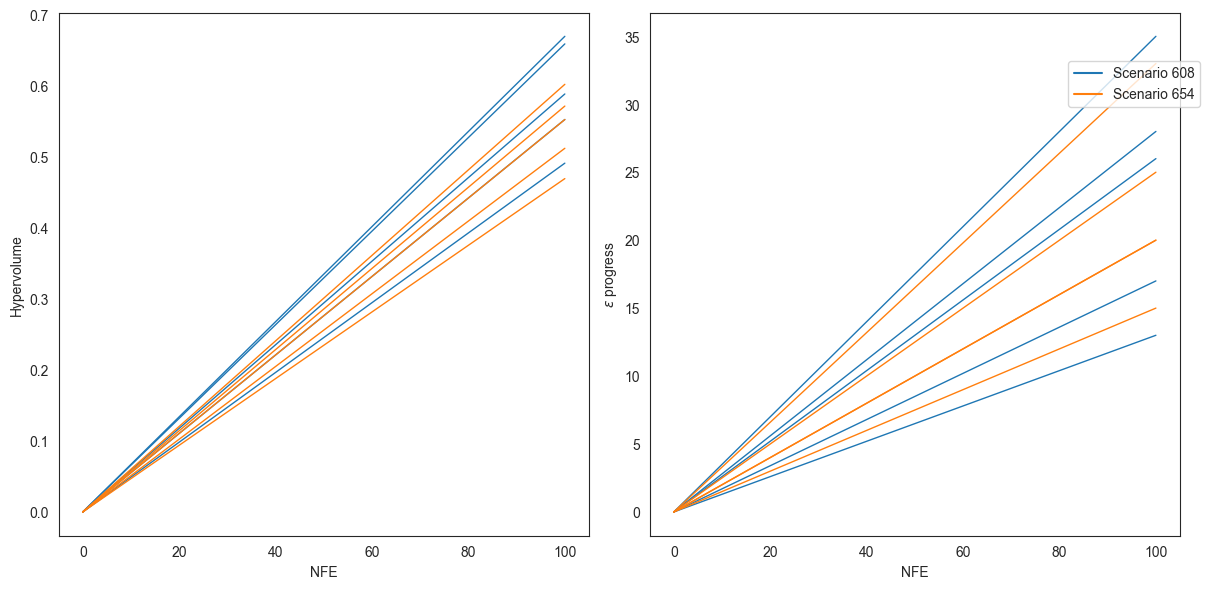

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D

# 📁 Inlezen
metrics_dir = "./convergence_metrics"
all_metrics = []

for file in os.listdir(metrics_dir):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(metrics_dir, file))
        all_metrics.append(df)

convergence = pd.concat(all_metrics, ignore_index=True)

# 🎨 Plotten
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
colors = sns.color_palette()
legend_items = []

for (scenario_name, group), color in zip(convergence.groupby("scenario"), colors):
    legend_items.append((Line2D([0], [0], color=color), scenario_name))

    for seed, score in group.groupby("seed"):
        ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
        ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)

ax1.set_ylabel("Hypervolume")
ax1.set_xlabel("NFE")
ax2.set_ylabel(r"$\epsilon$ progress")
ax2.set_xlabel("NFE")

artists, labels = zip(*legend_items)
fig.legend(artists, labels, bbox_to_anchor=(1.01, 0.9))
plt.tight_layout()
plt.show()


In [64]:
len(all_results)

10

In [72]:
import numpy as np

scenario_policy_counts = []

runs_per_scenario = 5
num_scenarios = len(all_results) // runs_per_scenario

for scenario_id in range(num_scenarios):
    scenario_valid_count = 0

    for run_id in range(runs_per_scenario):
        index = scenario_id * runs_per_scenario + run_id
        result_df = all_results[index]

        valid = (
                (result_df['A.5_Expected Number of Deaths'] < 1e-32) &
                (result_df['A.5 Total Costs'] < 60_000_000)
        )

        scenario_valid_count += np.sum(valid)

    scenario_policy_counts.append(scenario_valid_count)
    print(f"Scenario {scenario_id}: {scenario_valid_count} valid policies")







Scenario 0: 3 valid policies
Scenario 1: 4 valid policies


In [75]:
results

[   0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0        0        1        1        0        1        1        1        1   
 1        1        0        0        0        0        0        1        0   
 2        0        0        0        0        1        0        0        1   
 3        0        1        1        0        0        0        0        0   
 4        0        0        0        0        1        0        0        1   
 5        0        0        1        0        0        1        0        0   
 6        0        0        0        0        0        0        0        1   
 7        0        1        0        1        0        1        0        0   
 8        0        0        0        0        1        1        1        0   
 9        0        1        0        0        0        0        0        0   
 
    2_RfR 2  3_RfR 0  ...  A.4_DikeIncrease 0  A.4_DikeIncrease 1  \
 0        1        1  ...                   4                   6   
 1

In [76]:
import pandas as pd
import numpy as np
from ema_workbench import Policy

valid_policy_dfs = []
scenario_policy_counts = []
policies_to_evaluate = []

runs_per_scenario = 5
num_scenarios = len(all_results) // runs_per_scenario

for scenario_id in range(num_scenarios):
    scenario_valid_count = 0

    for run_id in range(runs_per_scenario):
        index = scenario_id * runs_per_scenario + run_id
        result_df = all_results[index]

        # Apply constraints
        valid = (
            (result_df['A.5_Expected Number of Deaths'] < 1e-32) &
            (result_df['A.5 Total Costs'] < 60_000_000)
        )

        # Extract valid rows
        valid_rows = result_df[valid]

        # Drop only the objective columns (not all outcomes)
        lever_only_df = valid_rows.drop(columns=objectives_of_interest)

        scenario_valid_count += len(lever_only_df)
        valid_policy_dfs.append(lever_only_df)

    scenario_policy_counts.append(scenario_valid_count)
    print(f"Scenario {scenario_id}: {scenario_valid_count} valid policies")

# Combine all valid policies
policies = pd.concat(valid_policy_dfs, ignore_index=True)

# Convert each row into a Policy object
for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))

print(f"\n✅ Total valid policies created: {len(policies_to_evaluate)}")




Scenario 0: 3 valid policies
Scenario 1: 4 valid policies

✅ Total valid policies created: 7


In [77]:
policies_to_evaluate

[Policy({'0_RfR 0': 1, '0_RfR 1': 0, '0_RfR 2': 1, '1_RfR 0': 1, '1_RfR 1': 0, '1_RfR 2': 0, '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1, '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 1, '4_RfR 0': 0, '4_RfR 1': 0, '4_RfR 2': 1, 'EWS_DaysToThreat': 1, 'A.1_DikeIncrease 0': 4, 'A.1_DikeIncrease 1': 5, 'A.1_DikeIncrease 2': 0, 'A.2_DikeIncrease 0': 7, 'A.2_DikeIncrease 1': 4, 'A.2_DikeIncrease 2': 4, 'A.3_DikeIncrease 0': 9, 'A.3_DikeIncrease 1': 10, 'A.3_DikeIncrease 2': 10, 'A.4_DikeIncrease 0': 3, 'A.4_DikeIncrease 1': 7, 'A.4_DikeIncrease 2': 10, 'A.5_DikeIncrease 0': 1, 'A.5_DikeIncrease 1': 4, 'A.5_DikeIncrease 2': 0}),
 Policy({'0_RfR 0': 0, '0_RfR 1': 1, '0_RfR 2': 0, '1_RfR 0': 0, '1_RfR 1': 0, '1_RfR 2': 1, '2_RfR 0': 1, '2_RfR 1': 0, '2_RfR 2': 0, '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 0, '4_RfR 0': 1, '4_RfR 1': 0, '4_RfR 2': 1, 'EWS_DaysToThreat': 0, 'A.1_DikeIncrease 0': 1, 'A.1_DikeIncrease 1': 9, 'A.1_DikeIncrease 2': 6, 'A.2_DikeIncrease 0': 2, 'A.2_DikeIncrease 1': 6, 'A.2_DikeIn

In [78]:
n_scenarios = 100
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████████| 700/700 [00:44<00:00, 15.78it/s]
[MainProcess/INFO] terminating pool


In [79]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)


def s_to_n(data, direction):
    mean = np.mean(data)
    std = np.std(data)

    if direction == ScalarOutcome.MAXIMIZE:
        return mean / std
    else:
        return mean * std

In [80]:
experiments, outcomes = results

overall_scores = {}
for policy in np.unique(experiments['policy']):
    scores = {}

    logical = experiments['policy'] == policy

    for outcome in dike_model.outcomes:
        value = outcomes[outcome.name][logical]
        sn_ratio = s_to_n(value, outcome.kind)
        scores[outcome.name] = sn_ratio
    overall_scores[policy] = scores
scores = pd.DataFrame.from_dict(overall_scores).T
scores

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1.632935e+00,0.000000e+00,1.678035e+14,1.216486e-08,1.646477e+01,0.000000e+00,1.366261e+14,6.209104e-08,1.951210e+15,2.094882e-05,0.0,2.643108e+05
1,3.873353e+16,1.825555e-03,1.077044e+16,5.095830e-04,6.936726e+14,2.976346e-05,4.012747e+13,2.245800e-08,3.584604e+15,6.801227e-04,0.0,0.000000e+00
2,1.107696e+14,1.947259e-10,3.161695e+15,6.584810e-07,5.332676e+15,1.730527e-05,2.564687e+14,1.429324e-07,2.101464e+14,6.141710e-08,0.0,3.553977e+06
3,0.000000e+00,0.000000e+00,3.892286e+14,3.416736e-07,1.202956e+14,4.613168e-07,2.755264e+14,2.416128e-06,1.726593e+14,1.597825e-06,0.0,0.000000e+00
4,1.155743e+14,5.471207e-10,7.046613e+15,3.041533e-06,3.448898e+15,5.050899e-06,3.039325e+14,3.569693e-08,1.113007e+15,1.706713e-06,0.0,4.420157e+06
5,7.818098e+15,5.578057e-06,6.525379e+13,5.461778e-11,1.812668e+15,3.731447e-06,6.318319e+13,1.136212e-09,4.642680e+15,1.436880e-05,0.0,7.571107e+06
6,6.430505e+00,0.000000e+00,5.476715e+13,5.010130e-10,3.211310e+00,0.000000e+00,3.439931e+14,1.629454e-06,6.336168e+15,2.037126e-04,0.0,2.429258e+06


/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

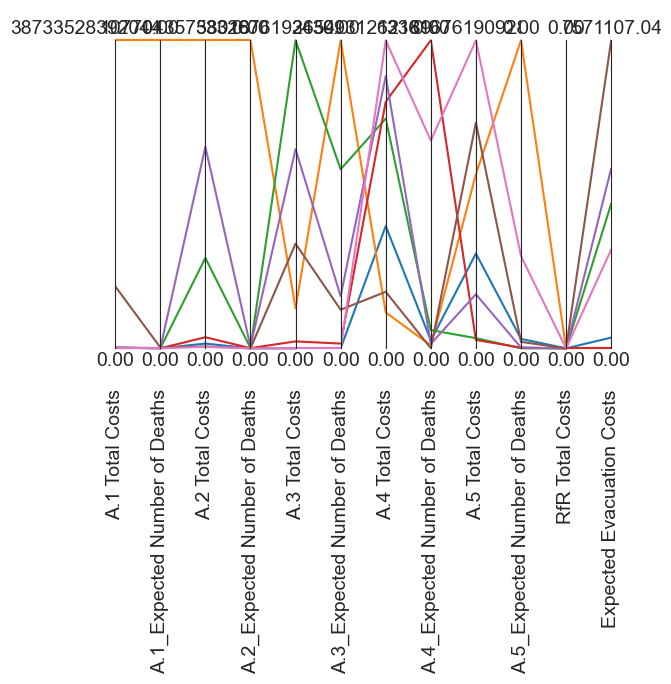

In [81]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = scores
limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)
#paraxes.invert_axis('A.5_Expected Number of Deaths')
plt.show()
#nog even duidelijker  maken

<Figure size 1200x600 with 0 Axes>

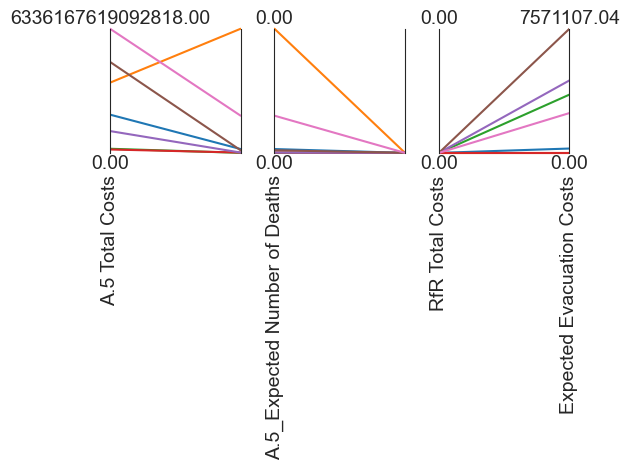

In [83]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

# Define the selected outcomes to focus on
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to only include selected outcomes
filtered_data = scores[selected_outcomes]

# Get limits and set lower bounds to 0
limits = parcoords.get_limits(filtered_data)
limits.loc[0, selected_outcomes] = 0

# Create the plot
plt.figure(figsize=(12, 6))  # Adjusted to match reduced number of axes

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

# Optionally invert axes if you want low deaths to be visually higher
# paraxes.invert_axis('A.5_Expected Number of Deaths')

plt.tight_layout()
plt.show()


In [84]:
def calculate_regret(data, best):
    return np.abs(best - data)

In [85]:
experiments, outcomes = results

overall_regret = {}
max_regret = {}
for outcome in dike_model.outcomes:
    policy_column = experiments['policy']

    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name],
                         "policy": experiments['policy'],
                         "scenario": experiments['scenario']})

    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')

    # flatten the resulting hierarchical index resulting from
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)

    # we need to control the broadcasting.
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()

    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()

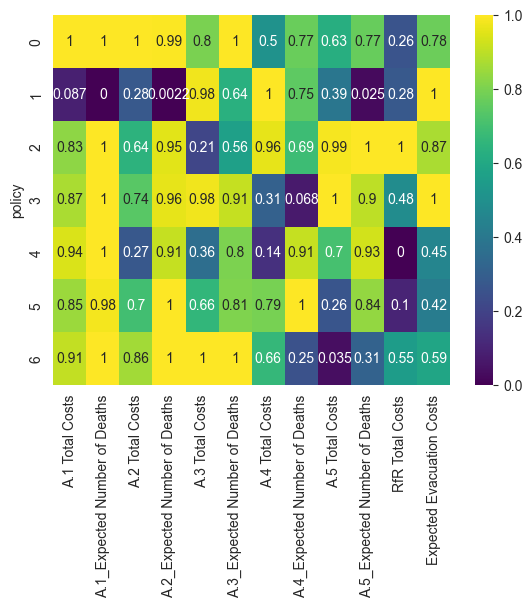

In [86]:
max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret / max_regret.max(), cmap='viridis', annot=True)
plt.show()

/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)
/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:281: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


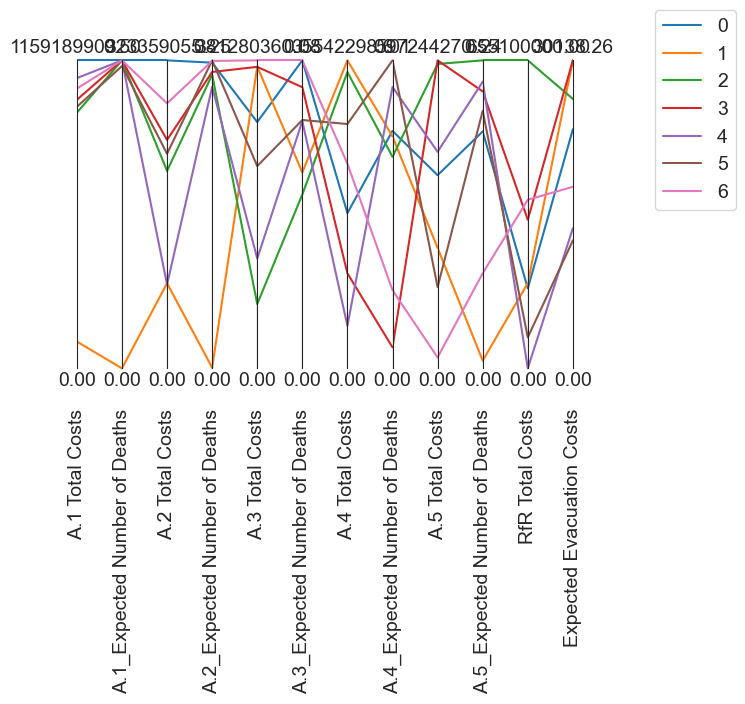

In [87]:
colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0

paraxes = parcoords.ParallelAxes(limits)
for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
paraxes.legend()

plt.show()

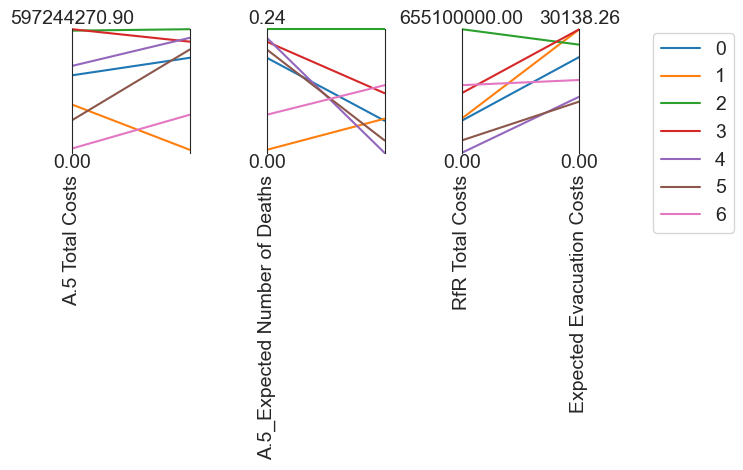

In [88]:
#betere leesbaarheid dan de vorige
import seaborn as sns
from ema_workbench.analysis import parcoords

colors = sns.color_palette()

# Select only the outcomes you want to plot
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to just those columns
data = max_regret[selected_outcomes]

# Set limits, and force minimums to 0
limits = parcoords.get_limits(data)
limits.loc[0, selected_outcomes] = 0  # Force y-axis minimums

# Create and draw parallel coordinate plot
paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i % len(colors)])

paraxes.legend()
plt.tight_layout()
plt.show()


In [89]:
from collections import defaultdict

policy_regret = defaultdict(dict)
for key, value in overall_regret.items():
    for policy in value:
        policy_regret[policy][key] = value[policy]

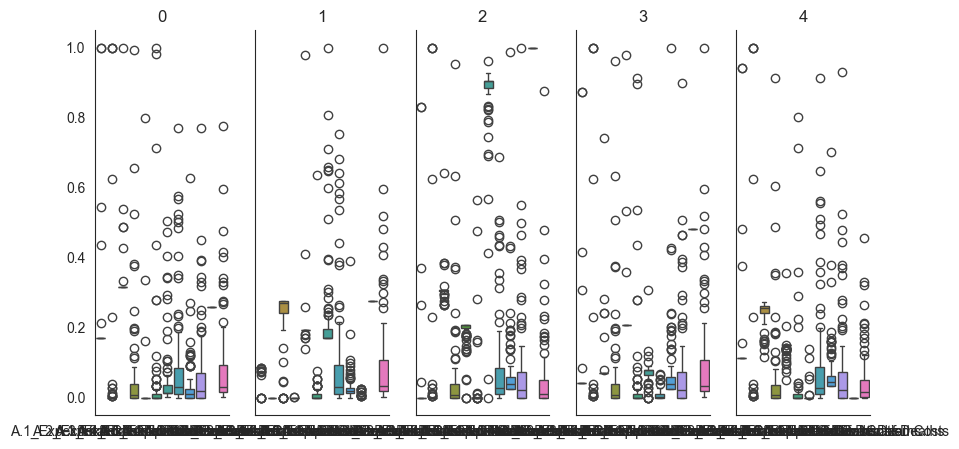

In [90]:
# this generates a 2 plots with a shared y and x axis
fig, axes = plt.subplots(ncols=5, figsize=(10, 5),
                         sharey=True, sharex=True)

# to ensure easy iteration over the axes grid, we turn it
# into a list. Because there are four plots, I hard coded
# this.


# zip allows us to zip together the list of axes and the list of
# key value pairs return by items. If we iterate over this
# it returns a tuple of length 2. The first item is the ax
# the second items is the key value pair.
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)

    # we need to scale the regret to ensure fair visual
    # comparison. We can do that by divding by the maximum regret
    data = data / max_regret.max(axis=0)
    sns.boxplot(data=data, ax=ax)

    # removes top and left hand black outline of axes
    sns.despine()

    # ensure we know which policy the figure is for
    ax.set_title(str(policy))
plt.show()

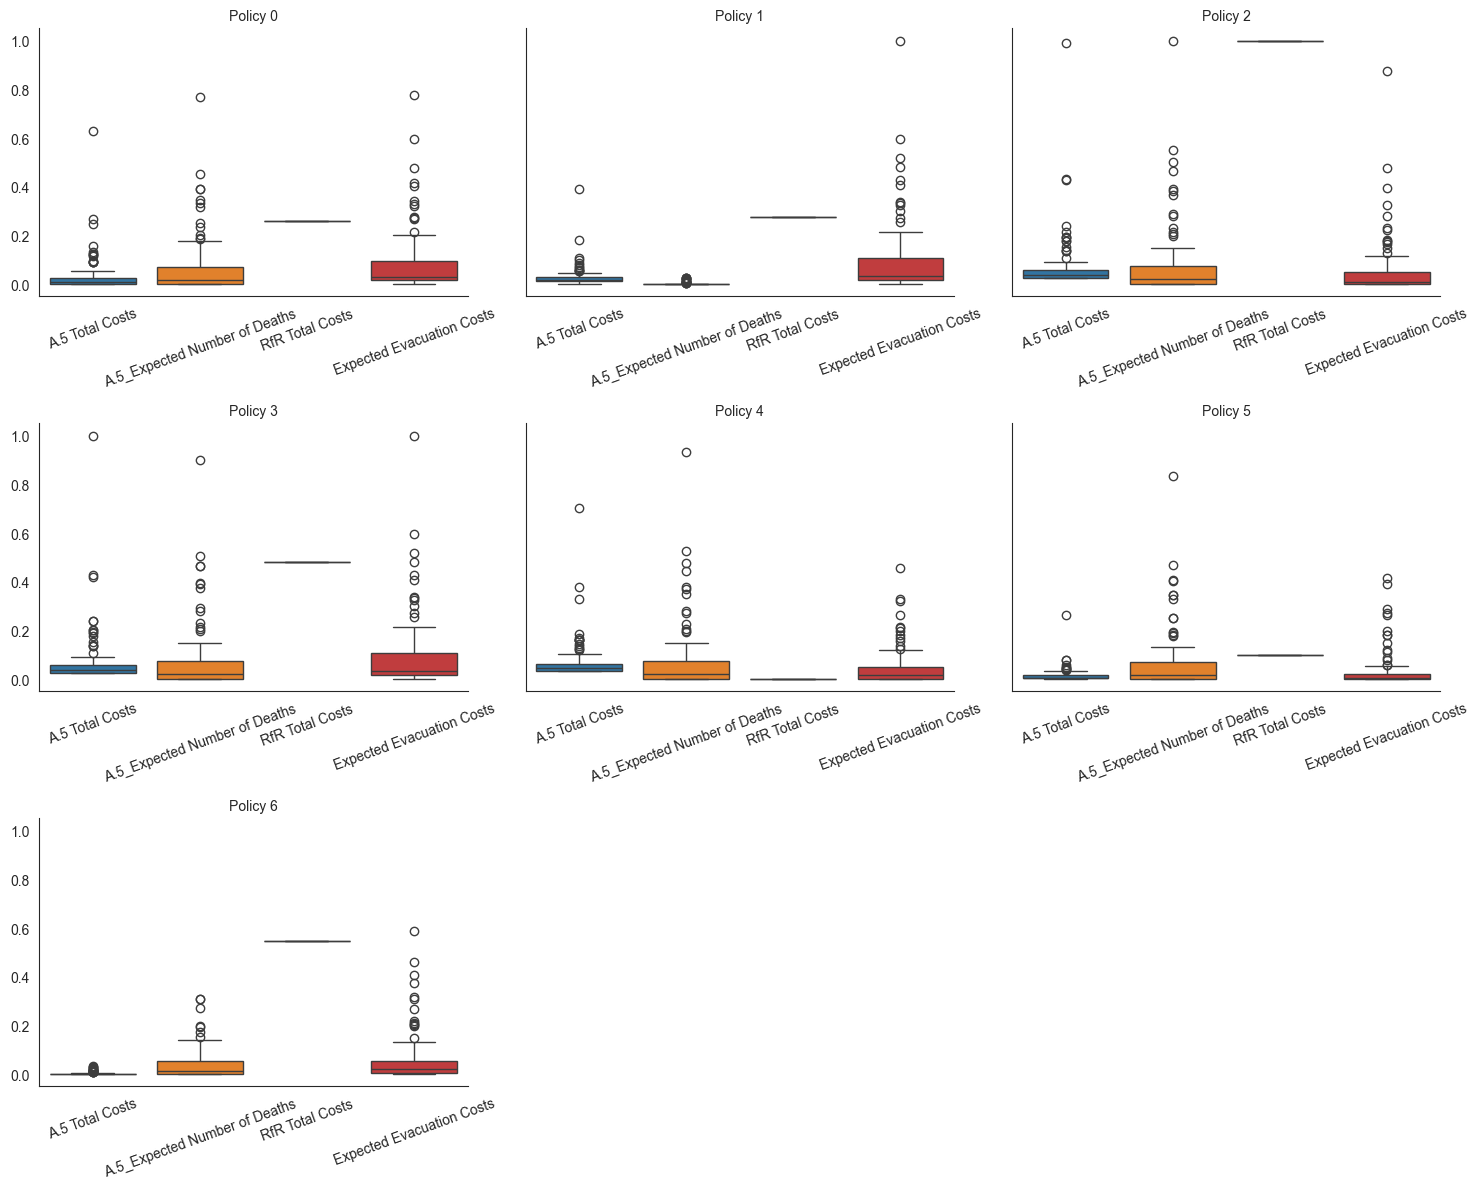

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Calculate number of policies
num_policies = len(policy_regret)
ncols = 3  # columns in grid
nrows = int(np.ceil(num_policies / ncols))  # rows in grid

# Create grid of subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=True)

# Flatten axes for easier indexing
axes = axes.flatten()

# Loop through policies and plot
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)
    data = data / max_regret.max(axis=0)
    data = data[selected_outcomes]

    sns.boxplot(data=data, ax=ax)
    ax.set_title(f"Policy {policy}", fontsize=10)
    ax.tick_params(axis='x', labelrotation=20)  # Rotate labels for readability
    sns.despine()

# Hide unused axes if any
for ax in axes[len(policy_regret):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

